# 02 · Post-mortem analysis — grafo de nodos producto/formato

Este notebook detecta aristas históricas que degradan OEE usando la misma granularidad definida en el EDA y en `07_statistical_analysis`:

- nodo = `marca × volumen × pack × envase`;
- arista = `prev_node → node`;
- tipo de arista = `C_brand`, `C_vol`, `C_pack`, `C_envase`, `C0_self`.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from bokeh.io import output_notebook, show
from bokeh.layouts import gridplot
from bokeh.models import Arrow, ColumnDataSource, HoverTool, LabelSet, VeeHead
from bokeh.plotting import figure

from data_loaders import LINES, load_all_operations
from post_mortem import PostMortemAnalyzer

DATA_DIR = Path('../raw_data')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
output_notebook()


Loading BokehJS ...

## 1 · Carga, limpieza y secuencias


In [2]:
ops = load_all_operations(DATA_DIR)
analyzer = PostMortemAnalyzer(
    df_oee=ops['oee'], df_cambios=ops['cam'], df_mantenimiento=ops['mant'],
    df_tiempo=ops['tiem'], df_volumen=ops['vol'],
)
df_clean = analyzer.clean_and_isolate_maintenance()
seq = analyzer.get_sequences()
transitions = seq[~seq['es_primera_of_semana']].copy()

print(f'OF limpias: {len(df_clean):,}')
print(f'Transiciones: {len(transitions):,}')
print(f'Nodos únicos: {seq["node"].nunique():,}')
print(f'Aristas únicas línea+nodo: {transitions.groupby(["tren","prev_node","node"]).ngroups:,}')
print('\nEjemplo de aristas:')
print(transitions[['tren','sku_prev','sku','prev_node','node','edge_type','freq_total','oee_seq']].dropna().head(10).to_string(index=False))


[clean_and_isolate_maintenance] OFs contaminadas (>20%): 293/2141 (13.7%)
  → imputadas por mediana SKU-línea (>50%): 105
OF limpias: 2,141
Transiciones: 1,986
Nodos únicos: 188
Aristas únicas línea+nodo: 1,358

Ejemplo de aristas:
tren sku_prev      sku                     prev_node                            node edge_type  freq_total  oee_seq
  14 VO13LTNN  VI13L6N     VOLL DAMM|1/3|UNI|KR00525         VICTORIA|1/3|P6|KR81115   C_brand    5.962500 0.412940
  14  ED12LTW  VI13L6N ESTRELLA DAMM|1/2|UNI|KR00127         VICTORIA|1/3|P6|KR81115   C_brand    1.093889 0.370797
  14  VI13L6N ED13LCMM       VICTORIA|1/3|P6|KR81115   ESTRELLA DAMM|1/3|UNI|KR00440   C_brand    2.640069 0.416225
  14  XI13LTN ED13LCMW        XIBECA|1/3|UNI|KR00716   ESTRELLA DAMM|1/3|UNI|KR00440   C_brand    1.866574 0.345156
  14 ED13LCMW VO13L6M1 ESTRELLA DAMM|1/3|UNI|KR00440        VOLL DAMM|1/3|P6|KR00525   C_brand    3.509306 0.292833
  14 VO13L6M1 VO13LTMN      VOLL DAMM|1/3|P6|KR00525       VOLL DAMM|1/3

## 2 · Matrices de transición por nodo

Las matrices ya no son SKU × SKU. Son `from_node × to_node`, con SKU observado como atributo en la tabla larga `_raw`.


In [3]:
matrices = analyzer.build_transition_matrices()
raw_all = []
for line, mats in matrices.items():
    raw = mats['_raw'].copy()
    raw['tren'] = line
    raw_all.append(raw)
raw_edges = pd.concat(raw_all, ignore_index=True)

print(raw_edges[['tren','prev_node','node','edge_type','sku_prev','sku','count','changeover_h_mean','oee_degradation']].head(12).to_string(index=False))
print('\nCobertura por línea:')
print(raw_edges.groupby('tren').agg(n_edges=('node','count'), n_prev_nodes=('prev_node','nunique'), n_nodes=('node','nunique'), mean_count=('count','mean')).round(2).to_string())


[build_transition_matrices] Línea 14: 236 transiciones únicas (59 nodos origen, 60 nodos destino)
[build_transition_matrices] Línea 17: 567 transiciones únicas (94 nodos origen, 93 nodos destino)
[build_transition_matrices] Línea 19: 555 transiciones únicas (115 nodos origen, 113 nodos destino)
tren                  prev_node                               node edge_type sku_prev      sku  count  changeover_h_mean  oee_degradation
  14     ARGUS|1/3|P12|KR6BNAGI             AURUM|1/3|P12|KR6BNAU7   C_brand 3BNAGLD5 3BNAULD1      1                NaN         0.126676
  14     AURUM|1/3|P12|KR6BNAU7             AURUM|1/3|P12|KR6BNAU7   C0_self 3BNAULD1 3BNAULD1      1                NaN         0.000000
  14     AURUM|1/3|P12|KR6BNAU7         DAMM LEMON|1/3|UNI|KR00928   C_brand 3BNAULD1   DL13LT      1           2.321019        -0.131245
  14     AURUM|1/3|P12|KR6BNAU7          EMD BRAU|1/3|P12|KR6BNEB9   C_brand 3BNAULD1 3BNEBL23      2                NaN        -0.018585
  14     AURUM

## 3 · Distribución de degradación y duración por tipo de arista


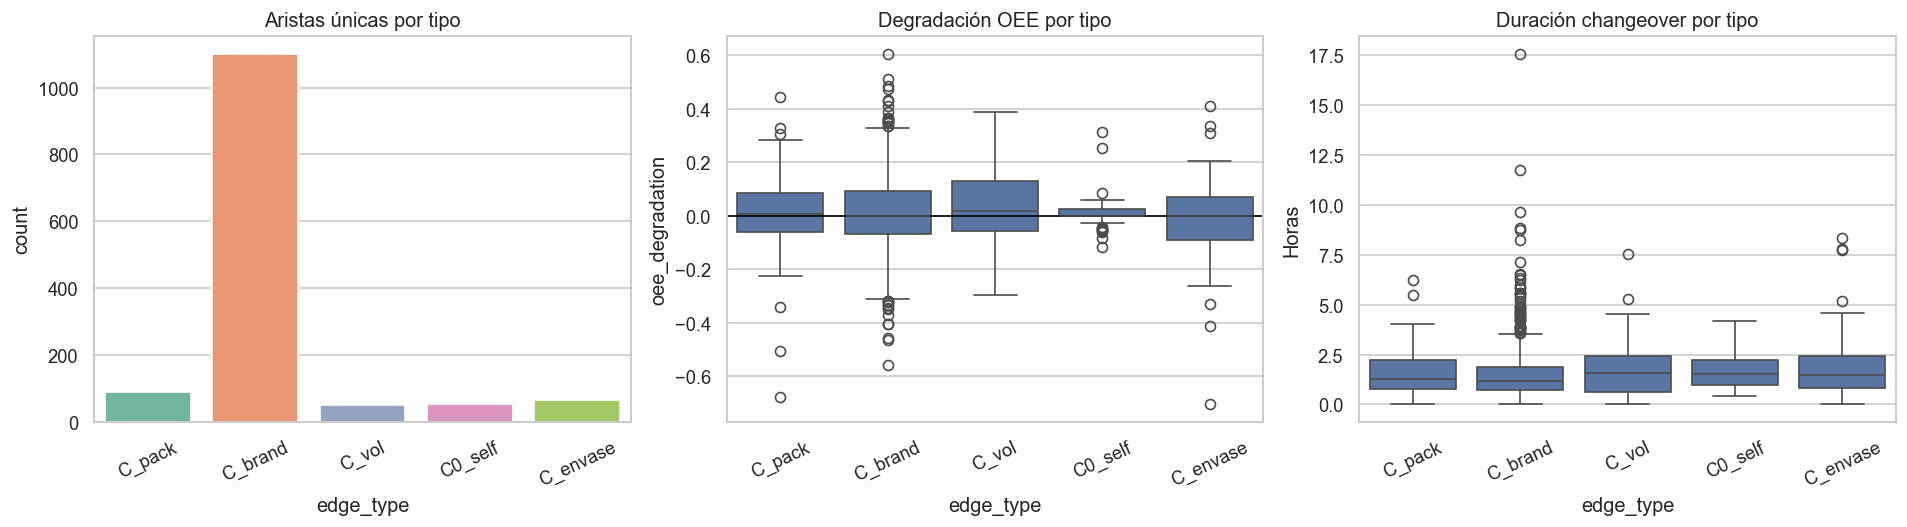

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = ['C_pack','C_brand','C_vol','C0_self','C_envase']
order = [x for x in order if x in raw_edges['edge_type'].unique()]

sns.countplot(data=raw_edges, x='edge_type', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Aristas únicas por tipo')
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(data=raw_edges, x='edge_type', y='oee_degradation', order=order, ax=axes[1])
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title('Degradación OEE por tipo')
axes[1].tick_params(axis='x', rotation=25)

plot_h = raw_edges.dropna(subset=['changeover_h_mean']).copy()
plot_h['changeover_h'] = np.where(plot_h['changeover_h_mean'] > 30, plot_h['changeover_h_mean']/60.0, plot_h['changeover_h_mean'])
sns.boxplot(data=plot_h, x='edge_type', y='changeover_h', order=order, ax=axes[2])
axes[2].set_title('Duración changeover por tipo')
axes[2].set_ylabel('Horas')
axes[2].tick_params(axis='x', rotation=25)

plt.tight_layout(); plt.show()


## 4 · Black spots: aristas que degradan OEE


In [5]:
black_spots = analyzer.detect_black_spots()
if black_spots.empty:
    print('No se detectaron black spots con el umbral actual.')
else:
    cols = ['tren','prev_node','node','edge_type','sku_prev','sku','count','oee_degradation','changeover_h_mean','hl_perdidos_estimados','gravedad']
    print(black_spots[cols].head(15).to_string(index=False))


[detect_black_spots] 21 black spots detectados (umbral degradación > μ + 1.5σ, mín. 2 ocurrencias)
tren                       prev_node                              node edge_type sku_prev      sku  count  oee_degradation  changeover_h_mean  hl_perdidos_estimados gravedad
  17          XIBECA|1/3|P12|KR00716         VOLL DAMM|1/3|UNI|KR00525   C_brand XI13L12M VO13LTNN      2         0.355537                NaN            1840.494571  crítica
  14   ESTRELLA DAMM|1/3|UNI|KR00444         EMD BRAU|1/3|P12|KR6BNEB9   C_brand ED13LCMM 3BNEBL23      3         0.140705           0.641250            1276.148552     alta
  17       FREE DAMM|1/3|UNI|KR00036 FREE DAMM TOSTADA|1/3|UNI|KR04806   C_brand   FD13LN  FDT13LT      4         0.250857           1.894861             825.729865  crítica
  19          XIBECA|1/3|P12|KR00719     ESTRELLA DAMM|1/3|P12|KR00443   C_brand XI13L12M ED1312MZ      2         0.271815           1.562639             623.674790  crítica
  19   ESTRELLA DAMM|1/3|UNI|KR

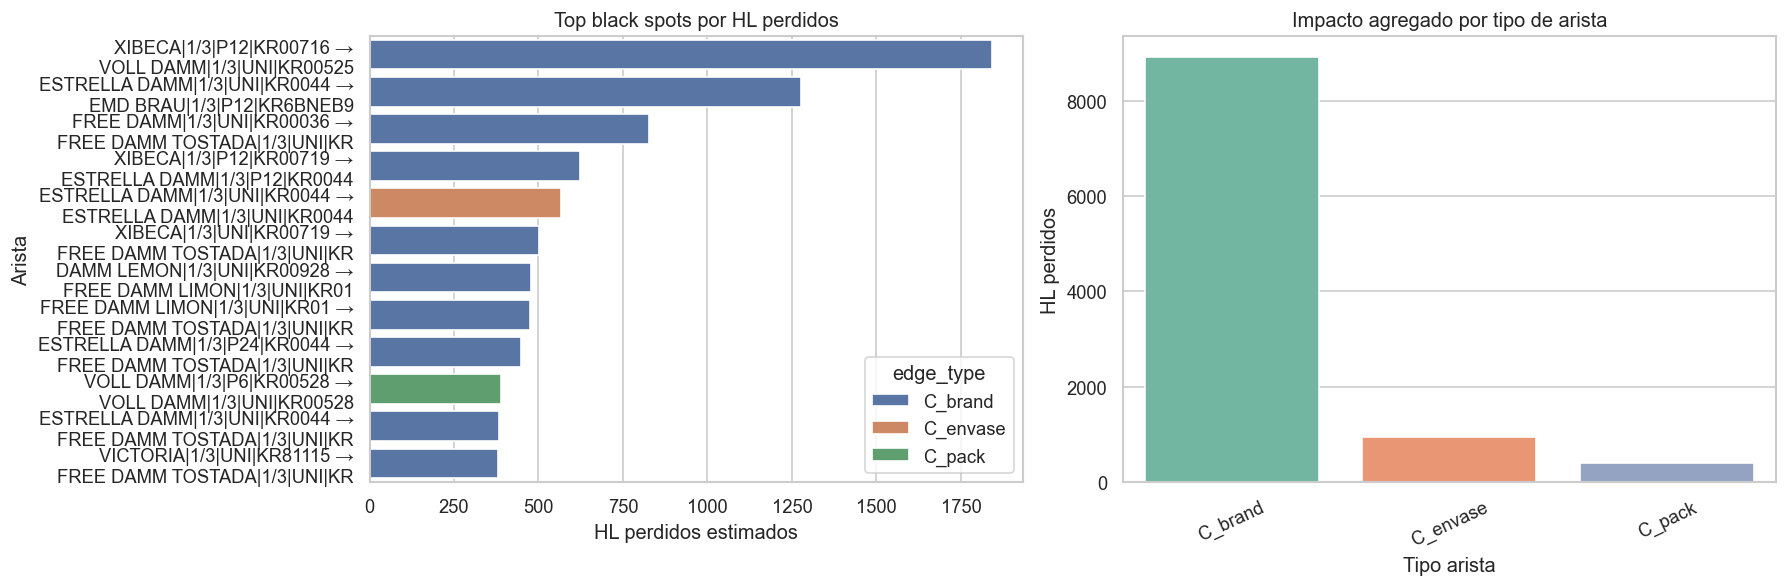

In [6]:
if not black_spots.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    top = black_spots.head(12).copy()
    top['edge_label'] = top['prev_node'].str.slice(0, 28) + ' →\n' + top['node'].str.slice(0, 28)
    sns.barplot(data=top, y='edge_label', x='hl_perdidos_estimados', hue='edge_type', dodge=False, ax=axes[0])
    axes[0].set_title('Top black spots por HL perdidos')
    axes[0].set_xlabel('HL perdidos estimados'); axes[0].set_ylabel('Arista')

    bs_type = black_spots.groupby('edge_type', as_index=False)['hl_perdidos_estimados'].sum().sort_values('hl_perdidos_estimados', ascending=False)
    sns.barplot(data=bs_type, x='edge_type', y='hl_perdidos_estimados', ax=axes[1], palette='Set2')
    axes[1].set_title('Impacto agregado por tipo de arista')
    axes[1].set_xlabel('Tipo arista'); axes[1].set_ylabel('HL perdidos')
    axes[1].tick_params(axis='x', rotation=25)
    plt.tight_layout(); plt.show()


## 5 · Grafo dirigido por línea

El grafo usa nodos producto/formato (`marca × volumen × pack × envase`). Los atributos de arista incluyen `edge_type`, `count`, `changeover_h` y degradación OEE.

La visualización se hace con Bokeh para inspeccionar nodos y transiciones: grosor = frecuencia histórica, color = tipo de arista y hover = métricas de nodo/arista.


In [7]:
graphs = analyzer.build_directed_graph()
graph_summary = []
for line, G in graphs.items():
    graph_summary.append({
        'line': line,
        'nodes': G.number_of_nodes(),
        'edges': G.number_of_edges(),
        'density': nx.density(G),
        'mean_in_degree': np.mean([d for _, d in G.in_degree()]),
        'mean_out_degree': np.mean([d for _, d in G.out_degree()]),
    })
print(pd.DataFrame(graph_summary).round(4).to_string(index=False))


[build_directed_graph] Línea 14: 63 nodos, 236 aristas
[build_directed_graph] Línea 17: 94 nodos, 567 aristas
[build_directed_graph] Línea 19: 117 nodos, 555 aristas
line  nodes  edges  density  mean_in_degree  mean_out_degree
  14     63    236   0.0604          3.7460           3.7460
  17     94    567   0.0649          6.0319           6.0319
  19    117    555   0.0409          4.7436           4.7436


In [8]:
EDGE_COLORS = {
    'C_brand': '#2563eb',   # cambio de marca
    'C_vol': '#d97706',     # cambio de volumen
    'C_pack': '#059669',    # cambio de pack/material
    'C_envase': '#dc2626',  # cambio de envase
    'C0_self': '#64748b',   # mismo nodo
    'desconocido': '#6b7280',
}


def short_node_label(node, max_len=26):
    text = str(node)
    return text if len(text) <= max_len else text[: max_len - 1] + '...'


def build_bokeh_graph_plot(G, line, top_edges=45):
    if G is None or G.number_of_edges() == 0:
        p = figure(
            title=f'L{line}: sin grafo',
            width=470,
            height=390,
            toolbar_location='above',
        )
        p.axis.visible = False
        p.grid.visible = False
        return p

    edge_data = sorted(
        G.edges(data=True),
        key=lambda x: x[2].get('count', 0),
        reverse=True,
    )[:top_edges]

    H = nx.DiGraph()
    for u, v, d in edge_data:
        H.add_node(u, **G.nodes[u])
        H.add_node(v, **G.nodes[v])
        H.add_edge(u, v, **d)

    pos = nx.spring_layout(H, seed=42, k=0.85, weight='count')
    degrees = dict(H.degree())
    max_degree = max(degrees.values()) if degrees else 1

    node_source = ColumnDataSource({
        'node': list(H.nodes()),
        'label': [short_node_label(n) for n in H.nodes()],
        'x': [pos[n][0] for n in H.nodes()],
        'y': [pos[n][1] for n in H.nodes()],
        'degree': [degrees.get(n, 0) for n in H.nodes()],
        'in_weight': [G.nodes[n].get('in_deg_weighted', 0.0) for n in H.nodes()],
        'out_weight': [G.nodes[n].get('out_deg_weighted', 0.0) for n in H.nodes()],
        'pagerank': [G.nodes[n].get('pagerank', 0.0) for n in H.nodes()],
        'size': [8 + 16 * degrees.get(n, 0) / max_degree for n in H.nodes()],
    })

    counts = [d.get('count', 1) for _, _, d in edge_data]
    max_count = max(counts) if counts else 1
    edge_rows = {
        'xs': [], 'ys': [], 'color': [], 'alpha': [], 'width': [],
        'edge_type': [], 'count': [], 'changeover_h': [], 'oee_degradation': [],
        'from_node': [], 'to_node': [],
    }

    for u, v, d in H.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_type = d.get('edge_type', 'desconocido')
        count = d.get('count', 1)
        edge_rows['xs'].append([x0, x1])
        edge_rows['ys'].append([y0, y1])
        edge_rows['color'].append(EDGE_COLORS.get(edge_type, EDGE_COLORS['desconocido']))
        edge_rows['alpha'].append(0.35 + 0.45 * count / max_count)
        edge_rows['width'].append(1.0 + 4.0 * count / max_count)
        edge_rows['edge_type'].append(edge_type)
        edge_rows['count'].append(count)
        edge_rows['changeover_h'].append(d.get('changeover_h', np.nan))
        edge_rows['oee_degradation'].append(d.get('weight', np.nan))
        edge_rows['from_node'].append(u)
        edge_rows['to_node'].append(v)

    edge_source = ColumnDataSource(edge_rows)

    p = figure(
        title=f'L{line}: top {len(edge_data)} aristas por frecuencia',
        width=470,
        height=390,
        tools='pan,wheel_zoom,box_zoom,reset,save',
        active_scroll='wheel_zoom',
        toolbar_location='above',
    )

    edge_renderer = p.multi_line(
        xs='xs',
        ys='ys',
        line_color='color',
        line_alpha='alpha',
        line_width='width',
        source=edge_source,
        legend_field='edge_type',
    )

    # Flechas separadas: Bokeh permite mantener hover limpio sobre las líneas.
    for u, v, d in H.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        color = EDGE_COLORS.get(d.get('edge_type', 'desconocido'), EDGE_COLORS['desconocido'])
        p.add_layout(Arrow(
            end=VeeHead(size=8, fill_color=color, line_color=color),
            x_start=x0,
            y_start=y0,
            x_end=x1,
            y_end=y1,
            line_color=color,
            line_alpha=0.45,
            line_width=1,
        ))

    node_renderer = p.scatter(
        x='x',
        y='y',
        size='size',
        fill_color='white',
        line_color='#111827',
        line_width=1.2,
        source=node_source,
    )

    labels = LabelSet(
        x='x',
        y='y',
        text='label',
        source=node_source,
        x_offset=5,
        y_offset=5,
        text_font_size='7pt',
        text_color='#111827',
        background_fill_color='white',
        background_fill_alpha=0.65,
    )
    p.add_layout(labels)

    p.add_tools(HoverTool(
        renderers=[node_renderer],
        tooltips=[
            ('Nodo', '@node'),
            ('Degree', '@degree'),
            ('In weight', '@in_weight{0.000}'),
            ('Out weight', '@out_weight{0.000}'),
            ('PageRank', '@pagerank{0.0000}'),
        ],
    ))
    p.add_tools(HoverTool(
        renderers=[edge_renderer],
        tooltips=[
            ('Tipo', '@edge_type'),
            ('Origen', '@from_node'),
            ('Destino', '@to_node'),
            ('Frecuencia', '@count'),
            ('Cambio h', '@changeover_h{0.00}'),
            ('Degradación OEE', '@oee_degradation{0.000}'),
        ],
    ))

    p.axis.visible = False
    p.grid.visible = False
    p.legend.location = 'top_left'
    p.legend.click_policy = 'hide'
    p.legend.background_fill_alpha = 0.75
    return p


plots = [build_bokeh_graph_plot(graphs.get(line), line) for line in LINES]
show(gridplot(plots, ncols=3, toolbar_location='above'))


## 6 · Métricas exportables


In [9]:
metrics = analyzer.export_explainability_metrics()
for name, df in metrics.items():
    print(f'\n{name} ({len(df)} filas)')
    print(df.head(8).to_string(index=False))


[export_explainability_metrics] Métricas de explicabilidad generadas:
  · top_black_spots: 10 filas
  · critical_nodes: 20 filas
  · weekly_oee_loss: 152 filas
  · line_summary: 3 filas

top_black_spots (10 filas)
Línea                     Nodo origen                      Nodo destino Tipo arista SKU origen observado SKU destino observado  OEE medio resultante  Degradación OEE  Veces ocurrido  Changeover medio (h)  HL perdidos estimados Gravedad
   17          XIBECA|1/3|P12|KR00716         VOLL DAMM|1/3|UNI|KR00525     C_brand             XI13L12M              VO13LTNN              0.316383         0.355537               2                   NaN            1840.494571  crítica
   14   ESTRELLA DAMM|1/3|UNI|KR00444         EMD BRAU|1/3|P12|KR6BNEB9     C_brand             ED13LCMM              3BNEBL23              0.369804         0.140705               3              0.641250            1276.148552     alta
   17       FREE DAMM|1/3|UNI|KR00036 FREE DAMM TOSTADA|1/3|UNI|KR04806     C_